---
##  Langkah 1 — Install Library

In [ ]:
!pip install -q transformers
!pip install -q accelerate
!pip install -q pandas tqdm


In [ ]:
# Download dataset from Google Drive
!pip install -q gdown
import gdown

# Google Drive file ID
file_id = "1z3AfTozCLktL35-SH9ukZG-Oxgb06etP"
output = "all_data.csv"

# Download file
gdown.download(f"https://drive.google.com/uc?id={file_id}", output, quiet=False)
print(f"Dataset downloaded: {output}")


Downloading...
From: https://drive.google.com/uc?id=1z3AfTozCLktL35-SH9ukZG-Oxgb06etP
To: /content/all_data.csv
100%|██████████| 794k/794k [00:00<00:00, 128MB/s]

Dataset downloaded: all_data.csv


---
##  Langkah 2 — Import Library & Konfigurasi Global

In [ ]:
import os
import time
import random
import warnings
import pandas as pd
import numpy as np
import torch
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
)

warnings.filterwarnings("ignore")

# Suppress transformers warnings
import logging
logging.getLogger('transformers').setLevel(logging.ERROR)
logging.getLogger('transformers.tokenization_utils').setLevel(logging.ERROR)

# --- Seed global agar hasil reproducible di setiap run ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(" Library berhasil diimpor")


 Library berhasil diimpor


In [ ]:

# KONFIGURASI UTAMA

CONFIG = {
    "input_csv_path": "all_data.csv",
    "output_csv_path": "all_data_augmented.csv",
    "model_name": "meta-llama/Meta-Llama-3-8B",
    "target_per_label": 2100,
    "emotion_labels": ["joy", "sad", "anger", "fear", "love", "neutral"],
    "batch_size": 32,
    "max_retries": 4,

    # Parameter generation model
    "generation_config": {
        "temperature": 0.7,
        "top_p": 0.9,
        "do_sample": True,
        "max_new_tokens": 128,
    },
}

print(" Konfigurasi berhasil dimuat")
print(f"   Model  : {CONFIG['model_name']}")
print(f"   Target : {CONFIG['target_per_label']} sample/label")
print(f"   Labels : {CONFIG['emotion_labels']}")


 Konfigurasi berhasil dimuat
   Model  : meta-llama/Meta-Llama-3-8B
   Target : 2100 sample/label
   Labels : ['joy', 'sad', 'anger', 'fear', 'love', 'neutral']


---
##  Langkah 3 — Load Dataset CSV

In [ ]:
def load_dataset(csv_path: str) -> pd.DataFrame:
    """
    Memuat dataset dari file CSV.
    Memastikan kolom yang diperlukan tersedia (index, tweet, label).
    """
    print(f"\n Memuat dataset dari: {csv_path}")
    df = pd.read_csv(csv_path)

    # Validasi kolom yang diperlukan
    required_cols = {"tweet", "label"}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Kolom berikut tidak ditemukan di CSV: {missing}")

    df = df.dropna(subset=["tweet", "label"])

    df["tweet"] = df["tweet"].astype(str).str.strip()

    df["label"] = df["label"].str.lower().str.strip()

    if "index" not in df.columns:
        df = df.reset_index(drop=False)

    print(f" Dataset berhasil dimuat: {len(df)} baris")
    print(f"   Kolom : {list(df.columns)}")
    return df

df_all = load_dataset(CONFIG["input_csv_path"])
df_all.head()


 Memuat dataset dari: all_data.csv
 Dataset berhasil dimuat: 7080 baris
   Kolom : ['index', 'tweet', 'label']


,index,tweet,label
0,0,pagi2 udah di buat emosi :),anger
1,1,"kok stabilitas negara, memange 10 thn negara t...",anger
2,2,dah lah emosi mulu liat emyu,anger
3,3,"aib? bodoh benar! sebelum kata aib itu muncul,...",anger
4,4,dih lu yg nyebelin bego,anger


---
##  Langkah 4 & 5 — Distribusi Label Awal & Kebutuhan Augmentasi


 Distribusi Label AWAL
----------------------------------------
  joy       :  1275
  sad       :  1003
  anger     :  1130
  fear      :   911
  love      :   760
  neutral   :  2001

  Total: 7080 baris


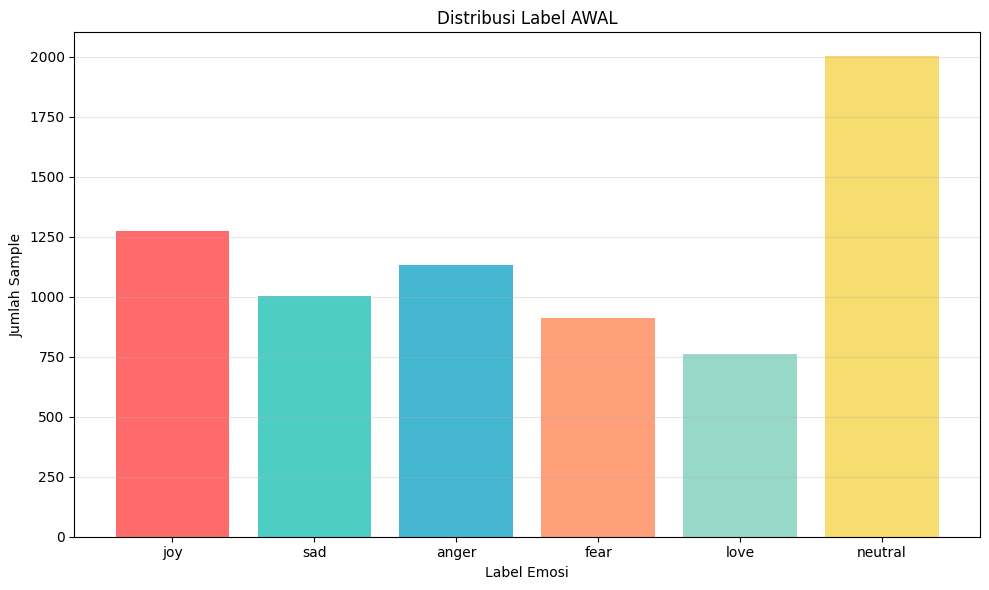


 Target per label: 2100 sample

 Kebutuhan augmentasi:
--------------------------------------------------
  joy       :  1275 saat ini ->   Butuh +825 sample
  sad       :  1003 saat ini ->   Butuh +1097 sample
  anger     :  1130 saat ini ->   Butuh +970 sample
  fear      :   911 saat ini ->   Butuh +1189 sample
  love      :   760 saat ini ->   Butuh +1340 sample
  neutral   :  2001 saat ini ->   Butuh +99 sample


In [ ]:
def analyze_distribution(df: pd.DataFrame, title: str = "Distribusi Label") -> dict:

    print(f"\n {title}")
    print("-" * 40)
    dist = df["label"].value_counts().to_dict()

    # Print text summary
    for label in CONFIG["emotion_labels"]:
        count = dist.get(label, 0)
        print(f"  {label:<10}: {count:>5}")

    print(f"\n  Total: {len(df)} baris")

    # Create bar chart using matplotlib
    labels = CONFIG["emotion_labels"]
    values = [dist.get(label, 0) for label in labels]

    plt.figure(figsize=(10, 6))
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#F7DC6F']
    plt.bar(labels, values, color=colors[:len(labels)])
    plt.title(title)
    plt.xlabel('Label Emosi')
    plt.ylabel('Jumlah Sample')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    return dist

def identify_augmentation_needs(dist: dict) -> dict:

    target = CONFIG["target_per_label"]
    needs = {}

    print(f"\n Target per label: {target} sample")
    print("\n Kebutuhan augmentasi:")
    print("-" * 50)

    for label in CONFIG["emotion_labels"]:
        current = dist.get(label, 0)
        needed = max(0, target - current)
        needs[label] = needed
        status = " Cukup" if needed == 0 else f"  Butuh +{needed} sample"
        print(f"  {label:<10}: {current:>5} saat ini -> {status}")

    return needs


# Tampilkan distribusi awal
dist_awal = analyze_distribution(df_all, title="Distribusi Label AWAL")

# Identifikasi kebutuhan augmentasi
augmentation_needs = identify_augmentation_needs(dist_awal)

---
##  Langkah 6 — Load Model Llama-3-8B (Base, BFloat16 Penuh — Tanpa Quantisasi)


In [ ]:
# Cek ketersediaan dan spesifikasi GPU
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    bf16_support = torch.cuda.is_bf16_supported()
    print(f"  GPU terdeteksi : {gpu_name}")
    print(f"   VRAM          : {vram:.1f} GB")


  GPU terdeteksi : NVIDIA A100-SXM4-40GB
   VRAM          : 42.4 GB


In [ ]:
from huggingface_hub import login
login()

def load_llama_model():

    model_name = CONFIG["model_name"]
    print(f"\n Memuat model: {model_name}")
    print(" Proses ini membutuhkan beberapa menit pertama kali (download + load)...")

    # Load tokenizer (kamus kata -> token ID)
    tokenizer = AutoTokenizer.from_pretrained(
        model_name,
        padding_side="left",
        trust_remote_code=True,
    )

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
        tokenizer.pad_token_id = tokenizer.eos_token_id

    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=torch.bfloat16,
        device_map="auto",
        trust_remote_code=True,
    )

    model.eval()

    if hasattr(model, 'hf_device_map') and model.hf_device_map:
        first_device = list(model.hf_device_map.values())[0]
        model_device = torch.device(f"cuda:{first_device}" if isinstance(first_device, int) else first_device)
    else:
        model_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    print("\n Model berhasil dimuat!")
    print(f"   Device    : {model_device}")
    print(f"   Dtype     : {model.dtype}")
    return tokenizer, model, model_device

# Load model dan tokenizer
tokenizer, model, model_device = load_llama_model()



 Memuat model: meta-llama/Meta-Llama-3-8B
 Proses ini membutuhkan beberapa menit pertama kali (download + load)...


config.json:   0%|          | 0.00/654 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/50.6k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/177 [00:00<?, ?B/s]


 Model berhasil dimuat!
   Device    : cuda
   Dtype     : torch.bfloat16


---
##  Langkah 7 — Prompt Template Augmentasi

In [ ]:
EMOTION_DESCRIPTIONS = {
    "joy":     "kebahagiaan, kesenangan, kegembiraan, atau antusiasme",
    "sad":     "kesedihan, dukacita, kekecewaan, atau rasa kehilangan",
    "anger":   "kemarahan, frustrasi, kejengkelan, atau ketidakpuasan",
    "fear":    "ketakutan, kekhawatiran, kecemasan, atau rasa was-was",
    "love":    "cinta, kasih sayang, rasa suka, atau rasa peduli",
    "neutral": "pernyataan netral tanpa emosi yang menonjol",
}

FEW_SHOT_EXAMPLES = [
    {
        "label": "joy",
        "original": "akhirnya libur juga, seneng banget rasanyaaa",
        "paraphrase": "yeay akhirnya libur, aku happy bgt gaes",
    },
    {
        "label": "sad",
        "original": "kenapa ya belakangan ini aku ngerasa sedih terus",
        "paraphrase": "entah kenapa akhir-akhir ini hatiku berat mulu, sedih aja gitu",
    },
    {
        "label": "anger",
        "original": "kesel banget diomongin di belakang mulu",
        "paraphrase": "gemes deh digosipin terus dari belakang, ga abis pikir",
    },
]


def build_augmentation_prompt(original_text: str, label: str) -> str:

    emotion_desc = EMOTION_DESCRIPTIONS.get(label, label)

    blocks = []
    for ex in FEW_SHOT_EXAMPLES:
        ex_desc = EMOTION_DESCRIPTIONS.get(ex["label"], ex["label"])
        blocks.append(
            f"Tweet asli: {ex['original']}\n"
            f"Emosi: {ex['label']} ({ex_desc})\n"
            f"Hasil parafrase: {ex['paraphrase']}"
        )

    few_shot_block = "\n\n".join(blocks)

    prompt = (
        "Berikut adalah beberapa contoh menulis ulang tweet Bahasa Indonesia dengan "
        "kata-kata berbeda namun tetap mempertahankan makna dan emosi aslinya. "
        "Gunakan gaya bahasa gaul/slang Twitter yang natural, tanpa tanda kutip, satu baris saja.\n\n"
        f"{few_shot_block}\n\n"
        f"Tweet asli: {original_text}\n"
        f"Emosi: {label} ({emotion_desc})\n"
        f"Hasil parafrase:"
    )

    return prompt


# Contoh prompt untuk verifikasi
contoh_prompt = build_augmentation_prompt("Hari ini sangat menyenangkan!", "joy")
print(" Contoh prompt yang akan dikirim ke model:")
print("-" * 60)
print(contoh_prompt)


 Contoh prompt yang akan dikirim ke model:
------------------------------------------------------------
Berikut adalah beberapa contoh menulis ulang tweet Bahasa Indonesia dengan kata-kata berbeda namun tetap mempertahankan makna dan emosi aslinya. Gunakan gaya bahasa gaul/slang Twitter yang natural, tanpa tanda kutip, satu baris saja.

Tweet asli: akhirnya libur juga, seneng banget rasanyaaa
Emosi: joy (kebahagiaan, kesenangan, kegembiraan, atau antusiasme)
Hasil parafrase: yeay akhirnya libur, aku happy bgt gaes

Tweet asli: kenapa ya belakangan ini aku ngerasa sedih terus
Emosi: sad (kesedihan, dukacita, kekecewaan, atau rasa kehilangan)
Hasil parafrase: entah kenapa akhir-akhir ini hatiku berat mulu, sedih aja gitu

Tweet asli: kesel banget diomongin di belakang mulu
Emosi: anger (kemarahan, frustrasi, kejengkelan, atau ketidakpuasan)
Hasil parafrase: gemes deh digosipin terus dari belakang, ga abis pikir

Tweet asli: Hari ini sangat menyenangkan!
Emosi: joy (kebahagiaan, kesenanga

---
##  Langkah 8 — Fungsi Validasi & Filter Duplikat

In [ ]:
def clean_generated_text(text: str) -> str:

    text = text.strip()

    # Ambil baris pertama non-kosong
    lines = [ln.strip() for ln in text.split("\n") if ln.strip()]
    text = lines[0] if lines else ""

    # Buang tanda kutip ganda yang nyelip di mana pun dalam kalimat
    text = text.replace('"', "")

    text = text.strip()
    if len(text) >= 2 and text.startswith("'") and text.endswith("'"):
        text = text[1:-1].strip()

    # Rapikan spasi ganda
    text = " ".join(text.split())

    return text


def is_valid_output(generated: str, original: str, existing_texts: set) -> bool:

    gen = generated.strip()

    # Validasi 0: Tidak kosong
    if not gen:
        return False

    # Validasi 1: Panjang minimum
    if len(gen.split()) < 5:
        return False

    # Validasi 2: Tidak duplikat (exact match)
    if gen in existing_texts:
        return False

    # Validasi 3: Jaccard similarity < 0.85 terhadap teks asli
    orig_tokens = set(original.lower().split())
    gen_tokens  = set(gen.lower().split())
    if orig_tokens and gen_tokens:
        intersection = orig_tokens & gen_tokens
        union = orig_tokens | gen_tokens
        jaccard = len(intersection) / len(union)
        if jaccard > 0.85:
            return False

    # Validasi 4: Bebas dari artefak token prompt Llama / sisa kutip
    artefak = ["tweet asli:", "hasil parafrase:", "<|", "|>",
               "system", "user", "assistant", '"', "berikut adalah",
               "berikut versi", "tentu,", "tentu saja,"]
    gen_lower = gen.lower()
    for artefak_str in artefak:
        if artefak_str in gen_lower:
            return False

    return True  # Semua validasi lolos


def extract_generated_text(output_ids, prompt_len: int, tokenizer) -> str:

    generated_ids = output_ids[prompt_len:]
    generated = tokenizer.decode(generated_ids, skip_special_tokens=True)
    return clean_generated_text(generated)


print(" Fungsi pembersihan, validasi, dan ekstraksi teks berhasil didefinisikan")


 Fungsi pembersihan, validasi, dan ekstraksi teks berhasil didefinisikan


---
##  Langkah 9 — Generate Data Augmentasi (Batching)

In [ ]:
def generate_augmented_samples(
    source_texts: list,
    label: str,
    num_needed: int,
    tokenizer,
    model,
    model_device,
    existing_texts: set,
) -> list:

    batch_size = CONFIG["batch_size"]
    gen_config = CONFIG["generation_config"]
    max_retries = CONFIG["max_retries"]

    augmented = []
    seen_texts = set(existing_texts)

    # Progress bar sederhana
    def show_progress(current, total, name):
        pct = int(100 * current / total) if total > 0 else 0
        filled = int(20 * current / total) if total > 0 else 0
        bar = chr(9608) * filled + chr(9617) * (20 - filled)
        print(f"\r{name}: [{bar}] {pct}% ({current}/{total})", end="", flush=True)

    print(f"\nAugmenting {label}:")
    show_progress(0, num_needed, label)

    while len(augmented) < num_needed:
        remaining = num_needed - len(augmented)
        current_batch = min(batch_size, remaining * max_retries)
        selected_sources = random.choices(source_texts, k=current_batch)

        prompts = [build_augmentation_prompt(src, label) for src in selected_sources]

        inputs = tokenizer(
            prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=768,
        )
        inputs = {k: v.to(model_device) for k, v in inputs.items()}

        prompt_len = inputs["input_ids"].shape[1]

        with torch.inference_mode():
            outputs = model.generate(
                **inputs,
                temperature=gen_config["temperature"],
                top_p=gen_config["top_p"],
                do_sample=gen_config["do_sample"],
                max_new_tokens=gen_config["max_new_tokens"],
                pad_token_id=tokenizer.pad_token_id,
                eos_token_id=tokenizer.eos_token_id,
            )

        for i, output_ids in enumerate(outputs):
            if len(augmented) >= num_needed:
                break
            generated = extract_generated_text(output_ids, prompt_len, tokenizer)
            if is_valid_output(generated, selected_sources[i], seen_texts):
                augmented.append(generated)
                seen_texts.add(generated)

        show_progress(len(augmented), num_needed, label)
        torch.cuda.empty_cache()

    print()
    return augmented


In [ ]:
# Set teks yang sudah ada untuk cek duplikat global
existing_texts = set(df_all["tweet"].tolist())

max_existing_index = df_all["index"].max() if "index" in df_all.columns else len(df_all)
next_index = int(max_existing_index) + 1

# Generasi untuk setiap label yang membutuhkan augmentasi
all_augmented_rows = []

for label, num_needed in augmentation_needs.items():

    # Skip label yang sudah cukup
    if num_needed == 0:
        print(f"\n    '{label}' sudah cukup ({dist_awal.get(label, 0)} sample). Dilewati.")
        continue

    # Ambil semua teks asli untuk label ini sebagai sumber parafrase
    source_texts = df_all[df_all["label"] == label]["tweet"].tolist()

    if not source_texts:
        print(f"\n    Tidak ada teks sumber untuk label '{label}'. Dilewati.")
        continue

    # Generate sample baru
    new_texts = generate_augmented_samples(
        source_texts=source_texts,
        label=label,
        num_needed=num_needed,
        tokenizer=tokenizer,
        model=model,
        model_device=model_device,
        existing_texts=existing_texts,
    )

    # Simpan hasil dengan index unik yang tidak bentrok
    for text in new_texts:
        all_augmented_rows.append({
            "index": next_index,
            "tweet": text,
            "label": label,
        })
        next_index += 1

    # Tambahkan teks baru ke set global
    existing_texts.update(new_texts)

print(f"\n Total sample augmentasi berhasil dibuat: {len(all_augmented_rows)}")


Augmenting joy:
joy: [████████████████████] 100% (825/825)

Augmenting sad:
sad: [████████████████████] 100% (1097/1097)

Augmenting anger:
anger: [████████████████████] 100% (970/970)

Augmenting fear:
fear: [████████████████████] 100% (1189/1189)

Augmenting love:
love: [████████████████████] 100% (1340/1340)

Augmenting neutral:
neutral: [████████████████████] 100% (99/99)

 Total sample augmentasi berhasil dibuat: 5520


---
##  Langkah 10 — Gabungkan Dataset & Tampilkan Distribusi Akhir

 Dataset asli      :   7080 baris
 Data augmentasi   :   5520 baris

 Dataset gabungan  :  12600 baris

 Distribusi Label AKHIR (setelah augmentasi)
----------------------------------------
  joy       :  2100
  sad       :  2100
  anger     :  2100
  fear      :  2100
  love      :  2100
  neutral   :  2100

  Total: 12600 baris


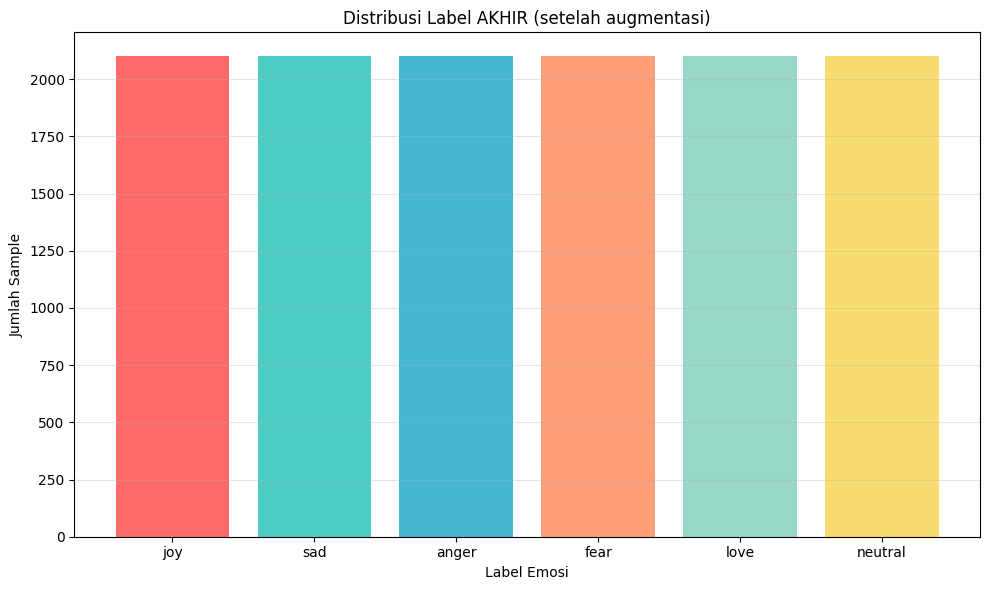

In [ ]:
df_augmented = pd.DataFrame(all_augmented_rows)

print(f" Dataset asli      : {len(df_all):>6} baris")
print(f" Data augmentasi   : {len(df_augmented):>6} baris")

# Gabungkan dataset asli dengan hasil augmentasi
df_final = pd.concat([df_all, df_augmented], ignore_index=True)

# Format output yang diinginkan: index, tweet, label
df_final = df_final[["index", "tweet", "label"]].copy()
df_final["tweet"] = df_final["tweet"].astype(str).str.strip()
df_final["label"] = df_final["label"].str.lower().str.strip()

print(f"\n Dataset gabungan  : {len(df_final):>6} baris")

# Tampilkan distribusi label akhir
dist_akhir = analyze_distribution(df_final, title="Distribusi Label AKHIR (setelah augmentasi)")

In [ ]:
# Ringkasan perubahan per label
print("\n Ringkasan Augmentasi per Label:")
print("-" * 55)
print(f"  {'Label':<10}  {'Sebelum':>8}  {'Sesudah':>8}  {'Tambahan':>10}")
print("-" * 55)

for label in CONFIG["emotion_labels"]:
    before = dist_awal.get(label, 0)
    after  = df_final[df_final["label"] == label].shape[0]
    added  = after - before
    print(f"  {label:<10}  {before:>8}  {after:>8}  {'+' + str(added):>10}")

print("-" * 55)
print(f"  {'TOTAL':<10}  {len(df_all):>8}  {len(df_final):>8}  {'+' + str(len(df_augmented)):>10}")

# Contoh hasil augmentasi
print("\n Contoh hasil augmentasi:")
df_augmented.sample(min(5, len(df_augmented)), random_state=SEED)


 Ringkasan Augmentasi per Label:
-------------------------------------------------------
  Label        Sebelum   Sesudah    Tambahan
-------------------------------------------------------
  joy             1275      2100        +825
  sad             1003      2100       +1097
  anger           1130      2100        +970
  fear             911      2100       +1189
  love             760      2100       +1340
  neutral         2001      2100         +99
-------------------------------------------------------
  TOTAL           7080     12600       +5520

 Contoh hasil augmentasi:


,index,tweet,label
1615,8695,"ya sedih aja, gak perlu ditambahin lagi",sad
4148,11228,"aku suka jijie, gak pede ngomongin tapi jadi s...",love
2683,9763,"ga enak rasanya, aku salah. apa lagi aku bodoh...",anger
5370,12450,aku jengkel banget sama orang-orang yang cuma ...,love
1871,8951,"ya ampun, ga pernah aku nolak cinta, ga pernah...",sad


---
##  Langkah 11 — Simpan Dataset Hasil Augmentasi ke CSV

In [ ]:
# Simpan dataset final ke CSV
output_path = CONFIG["output_csv_path"]
df_final.to_csv(output_path, index=False)

print(f" Dataset hasil augmentasi disimpan ke: {output_path}")
print(f"   Jumlah baris : {len(df_final)}")
print(f"   Kolom        : {list(df_final.columns)}")

# Verifikasi file berhasil disimpan
df_verify = pd.read_csv(output_path)
print(f"\n Verifikasi file berhasil: {len(df_verify)} baris terbaca")
df_verify.head()

 Dataset hasil augmentasi disimpan ke: all_data_augmented.csv
   Jumlah baris : 12600
   Kolom        : ['index', 'tweet', 'label']

 Verifikasi file berhasil: 12600 baris terbaca


,index,tweet,label
0,0,pagi2 udah di buat emosi :),anger
1,1,"kok stabilitas negara, memange 10 thn negara t...",anger
2,2,dah lah emosi mulu liat emyu,anger
3,3,"aib? bodoh benar! sebelum kata aib itu muncul,...",anger
4,4,dih lu yg nyebelin bego,anger


In [ ]:
# (Opsional) Download file CSV langsung dari Google Colab ke komputer lokal
try:
    from google.colab import files
    files.download(output_path)
    print(f" File '{output_path}' sedang diunduh ke komputer lokal...")
except ImportError:
    print("  Bukan di Google Colab. Unduh file secara manual dari file manager.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 File 'all_data_augmented.csv' sedang diunduh ke komputer lokal...
